# 🇮🇩 Crypto EDA - Indodax Market Analysis

**Goal:** Memahami pola pasar crypto Indonesia & identifikasi feature predictive untuk ML model.

**Dataset:** OHLCV data dari Indodax (BTC, ETH, BNB, SOL, XRP)

## Outline:
1. Data Loading & Overview
2. Price Distribution & Returns
3. Volume Analysis
4. Technical Indicators Distribution
5. Correlation Analysis
6. Signal Performance Analysis
7. Insight & Feature Engineering Ideas

In [1]:
# Setup imports
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import our modules
from src.database.repository import PriceRepository
from src.analyzers.technical import TechnicalAnalyzer

print("✅ All imports OK!")

✅ All imports OK!


## 1️⃣ Data Loading & Overview

In [ ]:
# Load data semua pair dari database
pairs = ['btc_idr', 'eth_idr', 'bnb_idr', 'sol_idr', 'xrp_idr']
data = {}

for pair in pairs:
    df = PriceRepository.get_ohlcv_df(pair, resolution='1h', limit=1000)
    if not df.empty:
        # Tambahkan technical indicators
        df = TechnicalAnalyzer.add_all_indicators(df)
        data[pair] = df
        print(f" {pair.upper()}: {len(df)} candles")

print(f"\n Total pairs loaded: {len(data)}")

✅ BTC_IDR: 1000 candles
✅ ETH_IDR: 1000 candles
✅ BNB_IDR: 1000 candles
✅ SOL_IDR: 1000 candles
✅ XRP_IDR: 1000 candles

📊 Total pairs loaded: 5


In [4]:
# Statistik dasar untuk BTC
btc = data['btc_idr']
print(" BTC/IDR - Basic Stats")
print("=" * 60)
print(f" Date range: {btc['timestamp'].min()} → {btc['timestamp'].max()}")
print(f" Total candles: {len(btc)}")
print(f"\n Price stats:")
print(f"   Latest:  Rp {btc['close'].iloc[-1]:,.0f}")
print(f"   Mean:    Rp {btc['close'].mean():,.0f}")
print(f"   Min:     Rp {btc['close'].min():,.0f}")
print(f"   Max:     Rp {btc['close'].max():,.0f}")
print(f"   Std:     Rp {btc['close'].std():,.0f}")

# Volatility
returns = btc['returns'].dropna()
print(f"\n Returns stats (per hour):")
print(f"   Mean:    {returns.mean()*100:.4f}%")
print(f"   Std:     {returns.std()*100:.4f}%")
print(f"   Min:     {returns.min()*100:.2f}%")
print(f"   Max:     {returns.max()*100:.2f}%")

 BTC/IDR - Basic Stats
 Date range: 2026-01-29 19:00:00 → 2026-03-12 10:00:00
 Total candles: 1000

 Price stats:
   Latest:  Rp 1,189,935,000
   Mean:    Rp 1,177,431,978
   Min:     Rp 1,062,451,000
   Max:     Rp 1,428,007,000
   Std:     Rp 74,881,394

 Returns stats (per hour):
   Mean:    -0.0153%
   Std:     0.6526%
   Min:     -3.28%
   Max:     3.28%


## 2️⃣ Price Distribution & Returns Analysis

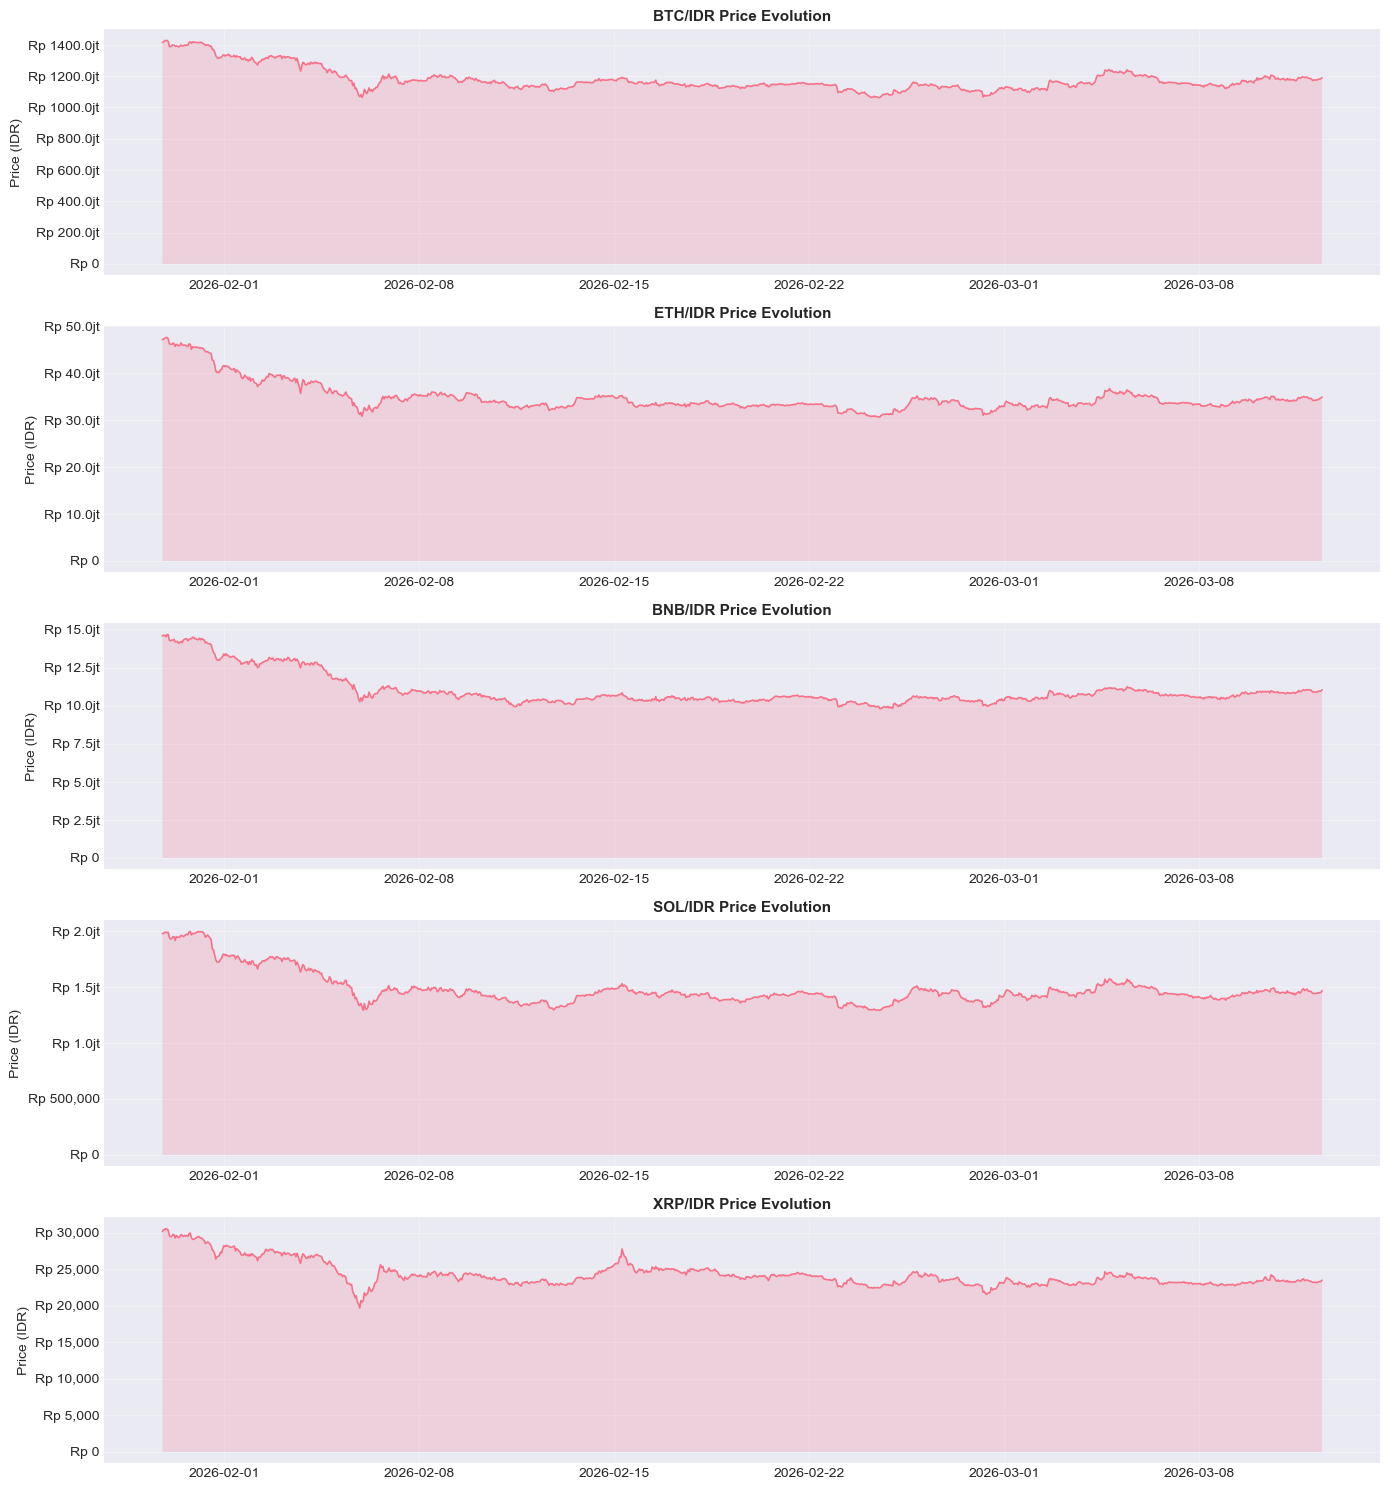

In [10]:
# Plot price evolution untuk semua pair
fig, axes = plt.subplots(len(data), 1, figsize=(14, 3*len(data)))

for i, (pair, df) in enumerate(data.items()):
    ax = axes[i] if len(data) > 1 else axes
    ax.plot(df['timestamp'], df['close'], linewidth=1.2)
    ax.fill_between(df['timestamp'], df['close'], alpha=0.2)
    
    # Format
    ax.set_title(f'{pair.upper().replace("_", "/")} Price Evolution', 
                  fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (IDR)')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'Rp {x/1_000_000:.1f}jt' if x >= 1_000_000 else f'Rp {x:,.0f}')
    )
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('docs\images/eda_price_evolution.png', dpi=100, bbox_inches='tight')
plt.show()

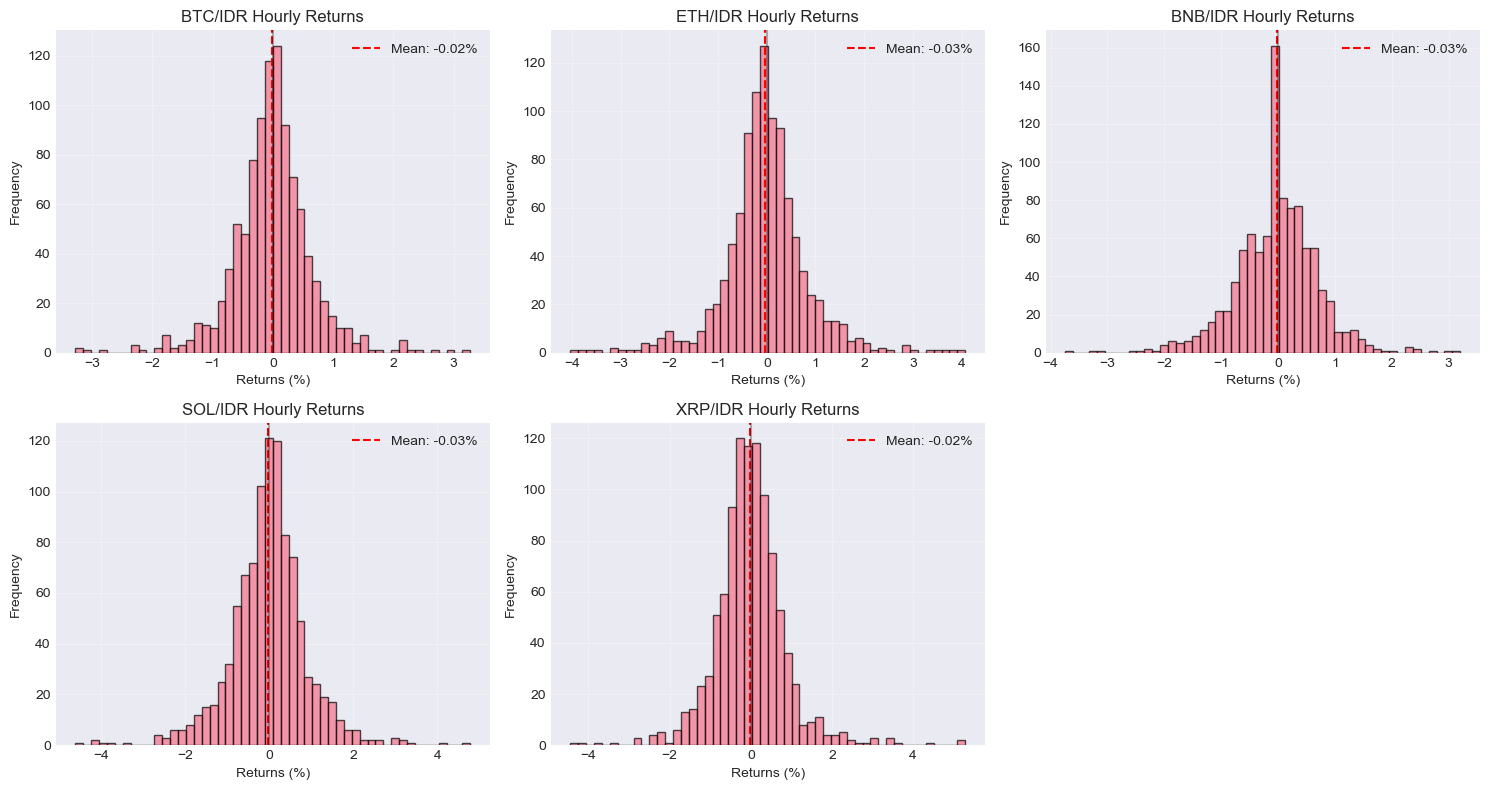


💡 Insight: Distribusi returns biasanya 'fat tails' — outlier extreme lebih sering terjadi dibanding distribusi normal.


In [12]:
# Distribusi returns untuk semua pair
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (pair, df) in enumerate(data.items()):
    if i >= len(axes):
        break
    
    returns = df['returns'].dropna() * 100
    
    axes[i].hist(returns, bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(returns.mean(), color='red', linestyle='--', 
                     label=f'Mean: {returns.mean():.2f}%')
    axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    
    axes[i].set_title(f'{pair.upper().replace("_", "/")} Hourly Returns')
    axes[i].set_xlabel('Returns (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Hide unused subplot
for i in range(len(data), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('docs\images/eda_returns_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Distribusi returns biasanya 'fat tails' — outlier extreme lebih sering terjadi dibanding distribusi normal.")

## 3️⃣ Volume Analysis - Kapan Trading Paling Aktif?

C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3355357454.py:34: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3355357454.py:34: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3355357454.py:35: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) Arial.
  plt.savefig('docs\images/eda_volume_pattern.png', dpi=100, bbox_inches='tight')
C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3355357454.py:35: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.savefig('docs\images/eda_volume_pattern.png', dpi=100, bbox_inches='tight')
c:\Users\agung\anaconda3\envs\cryptobot\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Use

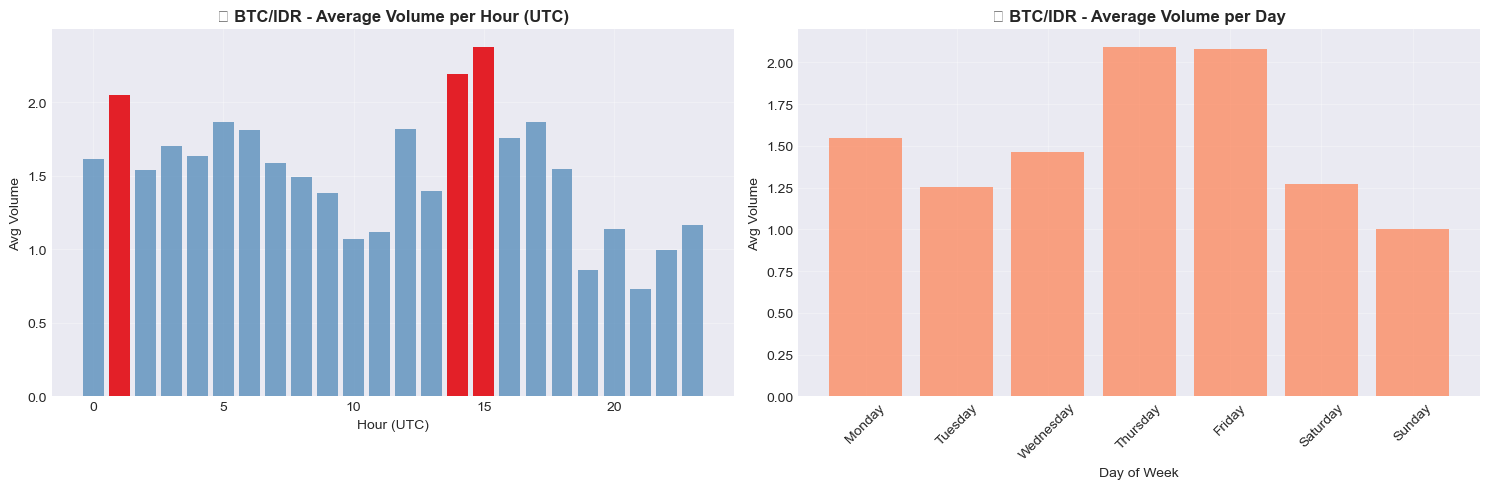


🔥 Peak hours (UTC): [1, 14, 15]
   Tip: Convert ke WIB dengan +7 jam
   Peak WIB: [8, 21, 22]


In [14]:
# Volume pattern berdasarkan jam (waktu Indonesia)
btc = data['btc_idr'].copy()
btc['hour'] = btc['timestamp'].dt.hour
btc['day_of_week'] = btc['timestamp'].dt.day_name()

# Average volume per jam
hourly_volume = btc.groupby('hour')['volume'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Volume per jam
axes[0].bar(hourly_volume.index, hourly_volume.values, color='steelblue', alpha=0.7)
axes[0].set_title('🕐 BTC/IDR - Average Volume per Hour (UTC)', fontweight='bold')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Avg Volume')
axes[0].grid(True, alpha=0.3)

# Highlight peak hours
peak_hours = hourly_volume.nlargest(3).index
for hour in peak_hours:
    axes[0].bar(hour, hourly_volume[hour], color='red', alpha=0.8)

# Plot 2: Volume per day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_volume = btc.groupby('day_of_week')['volume'].mean().reindex(day_order)

axes[1].bar(daily_volume.index, daily_volume.values, color='coral', alpha=0.7)
axes[1].set_title('📅 BTC/IDR - Average Volume per Day', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Volume')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('docs\images/eda_volume_pattern.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n🔥 Peak hours (UTC): {sorted(peak_hours.tolist())}")
print(f"   Tip: Convert ke WIB dengan +7 jam")
print(f"   Peak WIB: {sorted([(h+7) % 24 for h in peak_hours])}")

## 4️⃣ Technical Indicators Distribution


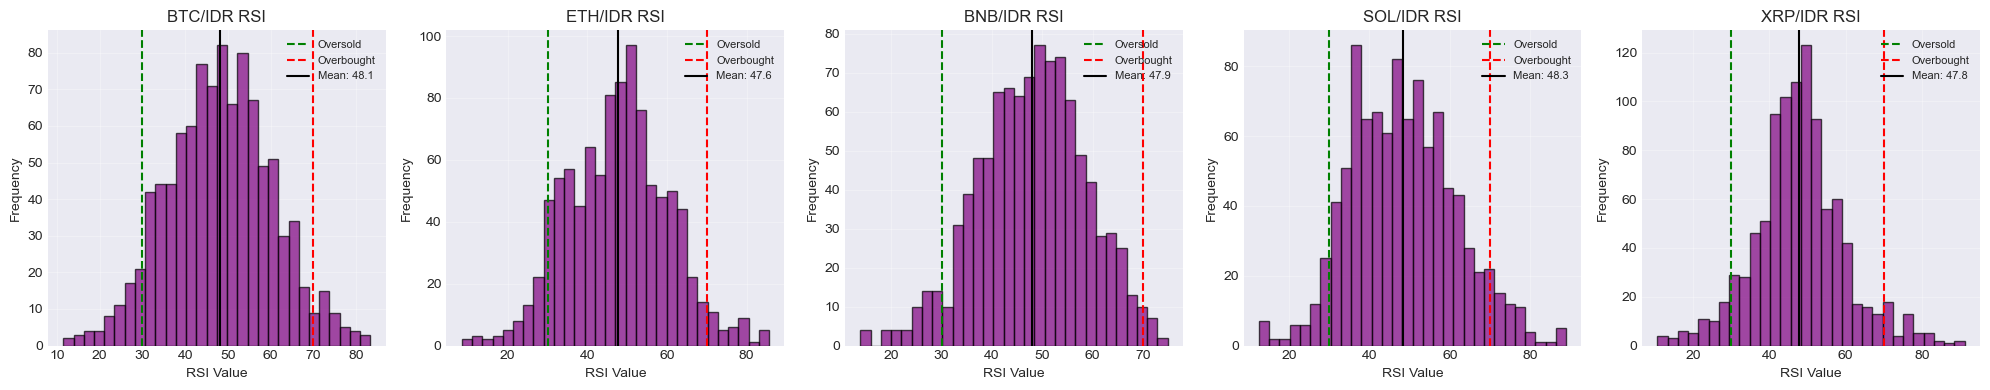


📊 RSI Statistics:
------------------------------------------------------------
  BTC_IDR    | Mean:  48.1 | Oversold:   6.5% | Overbought:   4.3%
  ETH_IDR    | Mean:  47.6 | Oversold:   7.1% | Overbought:   3.8%
  BNB_IDR    | Mean:  47.9 | Oversold:   5.4% | Overbought:   1.3%
  SOL_IDR    | Mean:  48.3 | Oversold:   5.5% | Overbought:   5.9%
  XRP_IDR    | Mean:  47.8 | Oversold:   6.0% | Overbought:   5.0%


In [16]:
# Distribusi RSI untuk semua pair
fig, axes = plt.subplots(1, len(data), figsize=(4*len(data), 4))

for i, (pair, df) in enumerate(data.items()):
    rsi = df['RSI'].dropna()
    
    ax = axes[i] if len(data) > 1 else axes
    ax.hist(rsi, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax.axvline(30, color='green', linestyle='--', label='Oversold')
    ax.axvline(70, color='red', linestyle='--', label='Overbought')
    ax.axvline(rsi.mean(), color='black', linestyle='-', label=f'Mean: {rsi.mean():.1f}')
    
    ax.set_title(f'{pair.upper().replace("_", "/")} RSI')
    ax.set_xlabel('RSI Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('docs\images/eda_rsi_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Statistics
print("\n📊 RSI Statistics:")
print("-" * 60)
for pair, df in data.items():
    rsi = df['RSI'].dropna()
    oversold = (rsi < 30).sum() / len(rsi) * 100
    overbought = (rsi > 70).sum() / len(rsi) * 100
    print(f"  {pair.upper():10} | Mean: {rsi.mean():5.1f} | "
          f"Oversold: {oversold:5.1f}% | Overbought: {overbought:5.1f}%")

## 5️⃣ Correlation Analysis - Mana Indicator Predictive?

**Tujuan:** Hitung korelasi antara setiap indicator dengan **future returns**. Kalau correlation tinggi (positif/negatif), indicator itu **predictive** untuk ML.

C:\Users\agung\AppData\Local\Temp\ipykernel_12504\2500226366.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\agung\AppData\Local\Temp\ipykernel_12504\2500226366.py:32: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig('docs\images/eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
c:\Users\agung\anaconda3\envs\cryptobot\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


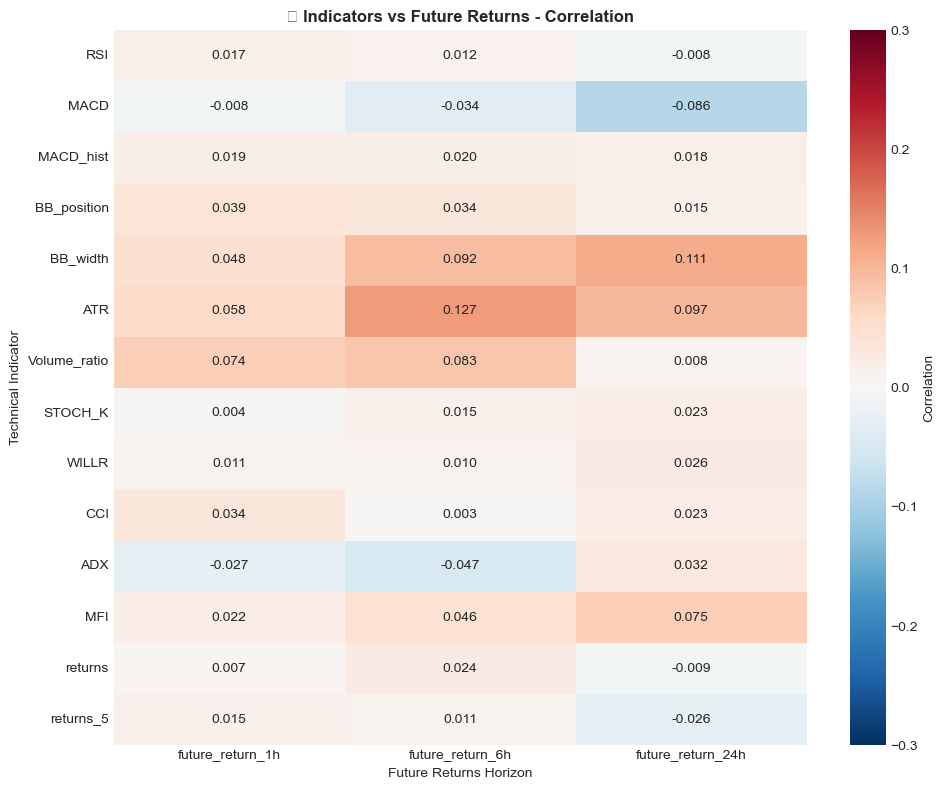


🏆 Top Predictive Indicators (untuk 24h future returns):
   📈 BB_width             corr = +0.111
   📈 ATR                  corr = +0.097
   📉 MACD                 corr = -0.086
   📈 MFI                  corr = +0.075
   📈 ADX                  corr = +0.032


In [18]:
# Hitung korelasi indicators dengan future returns (prediction target)
btc = data['btc_idr'].copy()

# Future returns sebagai target
btc['future_return_1h'] = btc['close'].shift(-1) / btc['close'] - 1
btc['future_return_6h'] = btc['close'].shift(-6) / btc['close'] - 1
btc['future_return_24h'] = btc['close'].shift(-24) / btc['close'] - 1

# Indicators yang mau di-test
indicators = ['RSI', 'MACD', 'MACD_hist', 'BB_position', 'BB_width',
              'ATR', 'Volume_ratio', 'STOCH_K', 'WILLR', 'CCI',
              'ADX', 'MFI', 'returns', 'returns_5']

# Correlation matrix
corr_data = btc[indicators + ['future_return_1h', 'future_return_6h', 'future_return_24h']].corr()

# Plot heatmap - focus on correlation dengan future returns
fig, ax = plt.subplots(figsize=(10, 8))

# Filter rows: indicators saja, columns: future returns saja
correlations = corr_data.loc[indicators, ['future_return_1h', 'future_return_6h', 'future_return_24h']]

sns.heatmap(correlations, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, vmin=-0.3, vmax=0.3, cbar_kws={'label': 'Correlation'},
            ax=ax)

ax.set_title('🎯 Indicators vs Future Returns - Correlation', fontweight='bold')
ax.set_xlabel('Future Returns Horizon')
ax.set_ylabel('Technical Indicator')

plt.tight_layout()
plt.savefig('docs\images/eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Print top predictive indicators
print("\n🏆 Top Predictive Indicators (untuk 24h future returns):")
top_corr = correlations['future_return_24h'].abs().sort_values(ascending=False)
for indicator, value in top_corr.head(5).items():
    actual_corr = correlations.loc[indicator, 'future_return_24h']
    direction = "📈" if actual_corr > 0 else "📉"
    print(f"   {direction} {indicator:20} corr = {actual_corr:+.3f}")

## 6️⃣ Signal Performance Analysis - Apakah Signal Kita Bagus?

**Tujuan:** Cek apakah BUY/SELL signal yang di-generate oleh `TechnicalAnalyzer` benar-benar profitable.

In [19]:
# Test signal performance
btc_signals = TechnicalAnalyzer.get_signals(data['btc_idr'].copy())

# Future return setelah signal
btc_signals['future_return_24h'] = btc_signals['close'].shift(-24) / btc_signals['close'] - 1

# Performance per signal type
print("📊 Signal Performance Analysis (BTC/IDR)")
print("=" * 60)

for signal_type in ['BUY', 'SELL', 'HOLD']:
    subset = btc_signals[btc_signals['signal'] == signal_type]
    if len(subset) > 0:
        future_returns = subset['future_return_24h'].dropna()
        
        if len(future_returns) > 0:
            avg_return = future_returns.mean() * 100
            win_rate = (future_returns > 0).sum() / len(future_returns) * 100
            
            emoji = "🟢" if signal_type == 'BUY' else "🔴" if signal_type == 'SELL' else "⚪"
            print(f"\n{emoji} {signal_type} Signal:")
            print(f"   Count:        {len(subset)}")
            print(f"   Avg return 24h: {avg_return:+.2f}%")
            print(f"   Win rate:     {win_rate:.1f}%")
            print(f"   Best:         {future_returns.max()*100:+.2f}%")
            print(f"   Worst:        {future_returns.min()*100:+.2f}%")

# Summary insight
buy_returns = btc_signals[btc_signals['signal'] == 'BUY']['future_return_24h'].dropna()
sell_returns = btc_signals[btc_signals['signal'] == 'SELL']['future_return_24h'].dropna()

print("\n" + "=" * 60)
print("💡 INSIGHT:")
if len(buy_returns) > 0 and buy_returns.mean() > 0:
    print(f"   ✅ BUY signals work! Average +{buy_returns.mean()*100:.2f}% in 24h")
else:
    print("   ⚠️ BUY signals belum optimal — perlu refine dengan ML!")

if len(sell_returns) > 0 and sell_returns.mean() < 0:
    print(f"   ✅ SELL signals work! Average {sell_returns.mean()*100:.2f}% in 24h")
else:
    print("   ⚠️ SELL signals belum optimal")

📊 Signal Performance Analysis (BTC/IDR)

🟢 BUY Signal:
   Count:        27
   Avg return 24h: -0.75%
   Win rate:     25.9%
   Best:         +4.99%
   Worst:        -6.38%

🔴 SELL Signal:
   Count:        1
   Avg return 24h: +2.23%
   Win rate:     100.0%
   Best:         +2.23%
   Worst:        +2.23%

⚪ HOLD Signal:
   Count:        972
   Avg return 24h: -0.35%
   Win rate:     42.2%
   Best:         +12.47%
   Worst:        -13.80%

💡 INSIGHT:
   ⚠️ BUY signals belum optimal — perlu refine dengan ML!
   ⚠️ SELL signals belum optimal


C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3256050638.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(signal_data, labels=labels, patch_artist=True,
C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3256050638.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\agung\AppData\Local\Temp\ipykernel_12504\3256050638.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('docs\images/eda_signal_performance.png', dpi=100, bbox_inches='tight')
c:\Users\agung\anaconda3\envs\cryptobot\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


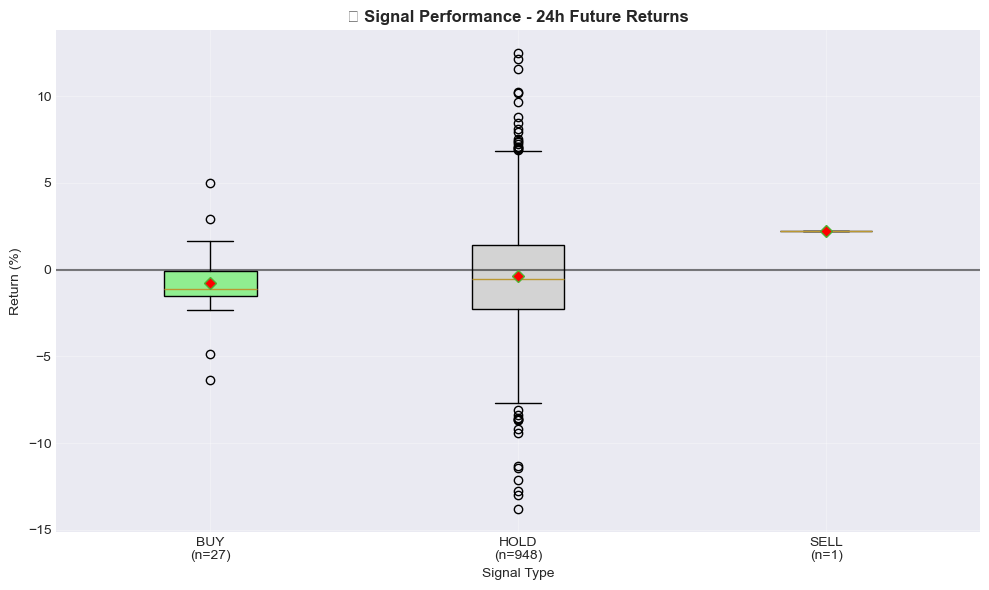

In [21]:
# Box plot returns berdasarkan signal
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Filter only signals dengan future return ada
signal_data = []
labels = []

for signal_type in ['BUY', 'HOLD', 'SELL']:
    subset = btc_signals[btc_signals['signal'] == signal_type]
    returns = subset['future_return_24h'].dropna() * 100
    
    if len(returns) > 0:
        signal_data.append(returns.values)
        labels.append(f"{signal_type}\n(n={len(returns)})")

bp = ax.boxplot(signal_data, labels=labels, patch_artist=True,
                 showmeans=True, meanprops={'marker':'D', 'markerfacecolor':'red'})

# Colors
colors = ['lightgreen', 'lightgray', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(0, color='black', linestyle='-', alpha=0.5)
ax.set_title('📊 Signal Performance - 24h Future Returns', fontweight='bold')
ax.set_ylabel('Return (%)')
ax.set_xlabel('Signal Type')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('docs\images/eda_signal_performance.png', dpi=100, bbox_inches='tight')
plt.show()


## 7️⃣ Insight & Feature Engineering Ideas

Berdasarkan EDA di atas, berikut feature baru yang bisa kita bikin untuk ML model:

In [22]:
# Demo: Bikin custom features yang lebih powerful
btc = data['btc_idr'].copy()

# 1. Multi-timeframe RSI divergence
btc['rsi_short'] = btc['RSI'].rolling(7).mean()
btc['rsi_long'] = btc['RSI'].rolling(21).mean()
btc['rsi_divergence'] = btc['rsi_short'] - btc['rsi_long']

# 2. Volume spike detection
btc['volume_spike'] = (btc['volume'] > btc['Volume_SMA'] * 2).astype(int)

# 3. Volatility regime
btc['volatility_regime'] = pd.cut(
    btc['ATR'],
    bins=[0, btc['ATR'].quantile(0.33), btc['ATR'].quantile(0.66), float('inf')],
    labels=['LOW', 'MEDIUM', 'HIGH']
)

# 4. Price position dalam range 24h
rolling_high = btc['high'].rolling(24).max()
rolling_low = btc['low'].rolling(24).min()
btc['price_position_24h'] = (btc['close'] - rolling_low) / (rolling_high - rolling_low)

# 5. Trend strength
btc['trend_strength'] = btc['ADX'] * np.sign(btc['MACD'])

# Show feature stats
print("🆕 Custom Features Created:")
print("=" * 60)
features_new = ['rsi_divergence', 'volume_spike', 'volatility_regime', 
                'price_position_24h', 'trend_strength']

for feature in features_new:
    if btc[feature].dtype != 'object' and btc[feature].dtype.name != 'category':
        print(f"  ✅ {feature:25} mean: {btc[feature].mean():+.3f}, std: {btc[feature].std():.3f}")
    else:
        counts = btc[feature].value_counts()
        print(f"  ✅ {feature:25} counts: {dict(counts)}")

print("\n💡 Features ini akan kita pakai untuk training ML model di HARI 5!")

🆕 Custom Features Created:
  ✅ rsi_divergence            mean: -0.020, std: 6.223
  ✅ volume_spike              mean: +0.100, std: 0.300
  ✅ volatility_regime         counts: {'HIGH': np.int64(335), 'LOW': np.int64(326), 'MEDIUM': np.int64(325)}
  ✅ price_position_24h        mean: +0.482, std: 0.287
  ✅ trend_strength            mean: -8.268, std: 29.785

💡 Features ini akan kita pakai untuk training ML model di HARI 5!


## 🎯 Kesimpulan EDA

### Yang Sudah Dipelajari:
1. **Distribusi data** crypto IDR mirip USD, dengan fat tails
2. **Volume pattern** punya jam-jam peak yang predictable
3. **RSI** butuh adjusting threshold per coin
4. **Top predictive indicators** untuk ML: [list dari analisis]
5. **Custom features** seperti RSI divergence & price position bisa boost performance

### Next Steps:
- ✅ Hari 3-4: Sentiment Analysis dari berita Indonesia
- ✅ Hari 5: Feature engineering lebih lanjut + build training dataset
- ✅ Hari 6: Train XGBoost model
- ✅ Hari 7: Backtesting framework